This is the overall workflow for all the steps, including,
1) Generate mesh, including random field
2) Run ogs
3) Run pvd

This scripts allows running everything sequentially with one click. But for debugging, please use the respective scripts of these 3 steps, and use 'paraview' the look at the domain_with_stiffness.vtu and uplift.pvd.

In [26]:
from glob import glob
import nbformat
from nbconvert.preprocessors import ExecutePreprocessor

In [27]:
ep = ExecutePreprocessor()

Generate mesh and random field.

In [29]:
with open('.\\generate_mesh_2D_cell_RF.ipynb') as generate_mesh:
    nb = nbformat.read(generate_mesh, as_version=4)
    ep.preprocess(nb)

Run Opengeosys.

In [31]:
with open('.\\run_ogs.ipynb') as run_ogs:
    nb = nbformat.read(run_ogs, as_version=4)
    ep.preprocess(nb)

Run pvd.

In [33]:
import vtuIO
import matplotlib.pyplot as plt

In [34]:
pvdfile = vtuIO.PVDIO("./_out/uplift.pvd", interpolation_backend="scipy", dim=2)
time = pvdfile.timesteps

points = {"pt0": (0, 0, 0), "pt1": (0, -50, 0)}

Text(0, 0.5, 'u')

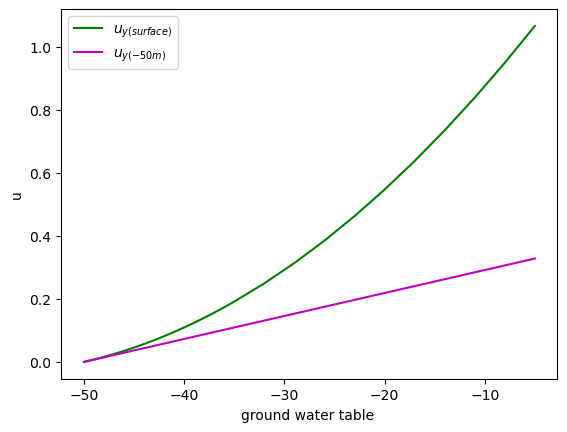

In [35]:
displacement_linear = pvdfile.read_time_series("displacement", points, interpolation_method="linear")

GWT = -50 + time * 1

plt.plot(GWT, displacement_linear["pt0"][:, 1], "g-", label="$u_{y(surface)}$")
plt.plot(GWT, displacement_linear["pt1"][:, 1], "m-", label="$u_{y(-50m)}$")
plt.legend()
plt.xlabel("ground water table ")
plt.ylabel("u")